# Stroke Prediction — Model Tuning
**Goal:** Improve model performance through threshold tuning and hyperparameter search.

Notebook order:
1. `01_eda.ipynb` ✓
2. `02_preprocessing.ipynb` ✓
3. `03_model_training.ipynb` ✓
4. `04_model_tuning.ipynb` ← you are here

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    precision_recall_curve, RocCurveDisplay
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PROCESSED_PATH = '../data/processed/'
MODELS_PATH    = '../models/'

X_train = pd.read_csv(PROCESSED_PATH + 'X_train.csv')
y_train = pd.read_csv(PROCESSED_PATH + 'y_train.csv').squeeze()
X_test  = pd.read_csv(PROCESSED_PATH + 'X_test.csv')
y_test  = pd.read_csv(PROCESSED_PATH + 'y_test.csv').squeeze()

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (7776, 10), Test: (1022, 10)


---
## Part A — Threshold Tuning

By default, classifiers use 0.5 as the decision threshold.
For stroke prediction, we want **high recall** — it is better to flag a false alarm than to miss a real stroke.
Lowering the threshold increases recall at the cost of precision.

In [2]:
# Retrain the baseline Logistic Regression (winner from notebook 3)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_proba = lr.predict_proba(X_test)[:, 1]

# Sweep thresholds and record precision, recall, F1
thresholds = np.arange(0.05, 0.95, 0.01)
records = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    records.append({
        'threshold': t,
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'recall':    recall_score(y_test, y_pred_t, zero_division=0),
        'f1':        f1_score(y_test, y_pred_t, zero_division=0),
    })

thresh_df = pd.DataFrame(records)
best_thresh_row = thresh_df.loc[thresh_df['f1'].idxmax()]
best_threshold  = best_thresh_row['threshold']

print(f'Best threshold by F1 : {best_threshold:.2f}')
print(f'  Precision : {best_thresh_row["precision"]:.4f}')
print(f'  Recall    : {best_thresh_row["recall"]:.4f}')
print(f'  F1        : {best_thresh_row["f1"]:.4f}')

Best threshold by F1 : 0.69
  Precision : 0.1854
  Recall    : 0.5600
  F1        : 0.2786


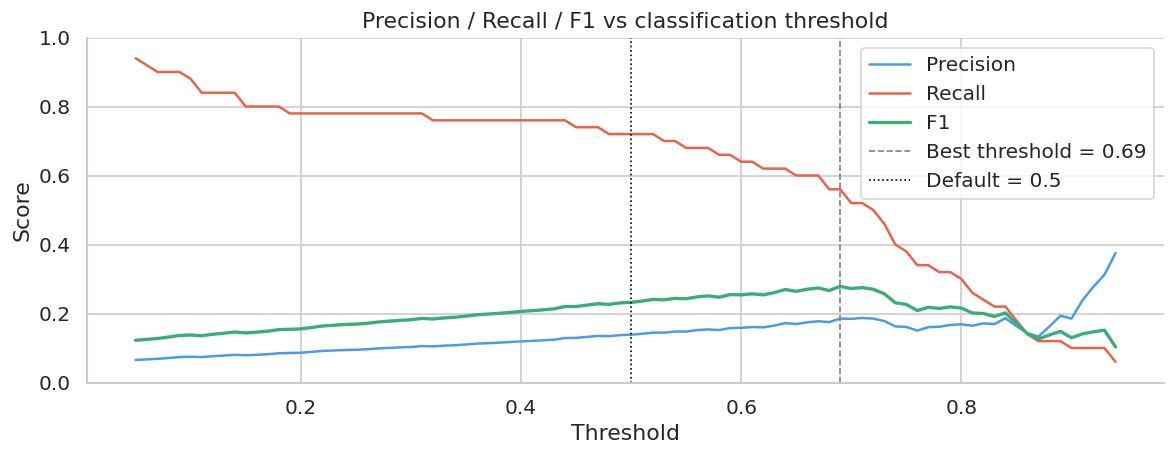

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', color='#4C9BE8')
ax.plot(thresh_df['threshold'], thresh_df['recall'],    label='Recall',    color='#E8634C')
ax.plot(thresh_df['threshold'], thresh_df['f1'],        label='F1',        color='#3BAE75', linewidth=2)
ax.axvline(best_threshold, color='gray', linestyle='--', linewidth=1,
           label=f'Best threshold = {best_threshold:.2f}')
ax.axvline(0.5, color='black', linestyle=':', linewidth=1, label='Default = 0.5')

ax.set_title('Precision / Recall / F1 vs classification threshold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(PROCESSED_PATH + 'tuning_threshold_curve.png', bbox_inches='tight')
plt.show()

In [4]:
# Compare default vs tuned threshold
y_pred_default = (y_proba >= 0.50).astype(int)
y_pred_tuned   = (y_proba >= best_threshold).astype(int)

comparison = pd.DataFrame({
    'Default (0.50)': [
        precision_score(y_test, y_pred_default, zero_division=0),
        recall_score(y_test, y_pred_default, zero_division=0),
        f1_score(y_test, y_pred_default, zero_division=0),
        roc_auc_score(y_test, y_proba),
    ],
    f'Tuned ({best_threshold:.2f})': [
        precision_score(y_test, y_pred_tuned, zero_division=0),
        recall_score(y_test, y_pred_tuned, zero_division=0),
        f1_score(y_test, y_pred_tuned, zero_division=0),
        roc_auc_score(y_test, y_proba),
    ],
}, index=['Precision', 'Recall', 'F1', 'ROC-AUC'])

print('Logistic Regression — default vs tuned threshold:')
print(comparison.round(4))

Logistic Regression — default vs tuned threshold:
           Default (0.50)  Tuned (0.69)
Precision          0.1385        0.1854
Recall             0.7200        0.5600
F1                 0.2323        0.2786
ROC-AUC            0.7823        0.7823


---
## Part B — Hyperparameter Tuning with GridSearchCV
We tune the top 3 models from notebook 3: Logistic Regression, Gradient Boosting, and Random Forest.
We optimise for **ROC-AUC** since it is threshold-independent and best suited for imbalanced medical data.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grids = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C':       [0.01, 0.1, 1, 10, 100],
            'penalty': ['l1', 'l2'],
            'solver':  ['liblinear'],
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators':  [100, 200],
            'learning_rate': [0.05, 0.1, 0.2],
            'max_depth':     [3, 4, 5],
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth':    [None, 10, 20],
            'min_samples_split': [2, 5],
            'class_weight': ['balanced', None],
        }
    },
}

print('Starting GridSearchCV — this will take a few minutes...')

Starting GridSearchCV — this will take a few minutes...


In [6]:
grid_results = {}

for name, config in param_grids.items():
    print(f'Tuning {name}...')
    grid = GridSearchCV(
        config['model'], config['params'],
        cv=cv, scoring='roc_auc',
        n_jobs=-1, verbose=0
    )
    grid.fit(X_train, y_train)

    y_pred  = grid.best_estimator_.predict(X_test)
    y_proba = grid.best_estimator_.predict_proba(X_test)[:, 1]

    grid_results[name] = {
        'best_params': grid.best_params_,
        'cv_auc':      grid.best_score_,
        'test_auc':    roc_auc_score(y_test, y_proba),
        'test_f1':     f1_score(y_test, y_pred),
        'test_recall': recall_score(y_test, y_pred),
        'estimator':   grid.best_estimator_,
        'proba':       y_proba,
    }
    print(f'  Best params : {grid.best_params_}')
    print(f'  CV ROC-AUC  : {grid.best_score_:.4f}')
    print(f'  Test ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')
    print(f'  Test F1     : {f1_score(y_test, y_pred):.4f}')
    print(f'  Test Recall : {recall_score(y_test, y_pred):.4f}')
    print()

Tuning Logistic Regression...
  Best params : {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
  CV ROC-AUC  : 0.8899
  Test ROC-AUC: 0.7814
  Test F1     : 0.2323
  Test Recall : 0.7200

Tuning Gradient Boosting...
  Best params : {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
  CV ROC-AUC  : 0.9927
  Test ROC-AUC: 0.7554
  Test F1     : 0.1443
  Test Recall : 0.1400

Tuning Random Forest...
  Best params : {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  CV ROC-AUC  : 0.9904
  Test ROC-AUC: 0.7667
  Test F1     : 0.1429
  Test Recall : 0.1800



---
## Part C — Compare tuned models and pick the final winner

In [7]:
tuned_df = pd.DataFrame([
    {
        'Model':      name,
        'CV AUC':     v['cv_auc'],
        'Test AUC':   v['test_auc'],
        'Test F1':    v['test_f1'],
        'Test Recall':v['test_recall'],
    }
    for name, v in grid_results.items()
]).sort_values('Test AUC', ascending=False).set_index('Model').round(4)

print('Tuned model comparison:')
print(tuned_df)

Tuned model comparison:
                     CV AUC  Test AUC  Test F1  Test Recall
Model                                                      
Logistic Regression  0.8899    0.7814   0.2323         0.72
Random Forest        0.9904    0.7667   0.1429         0.18
Gradient Boosting    0.9927    0.7554   0.1443         0.14


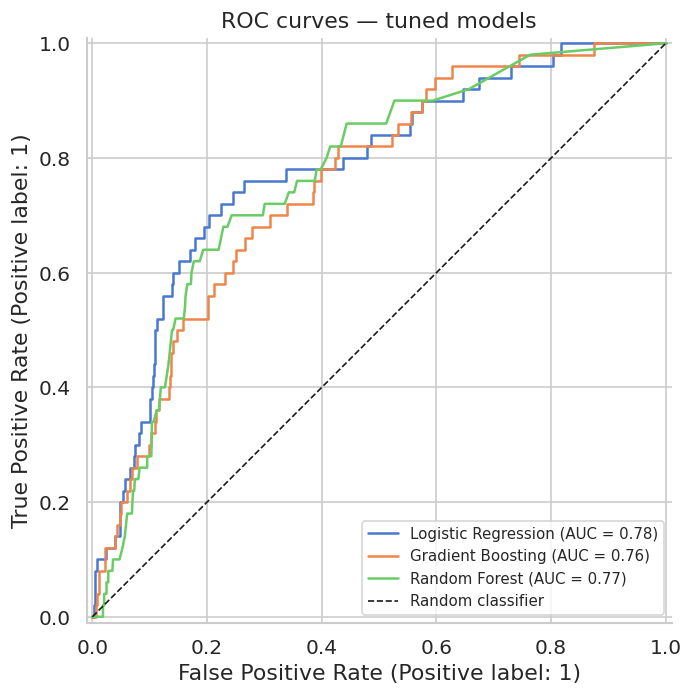

In [8]:
# ROC curves for all tuned models
fig, ax = plt.subplots(figsize=(8, 6))
for name, v in grid_results.items():
    RocCurveDisplay.from_estimator(
        v['estimator'], X_test, y_test, ax=ax, name=name
    )
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_title('ROC curves — tuned models')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(PROCESSED_PATH + 'tuning_roc_curves.png', bbox_inches='tight')
plt.show()

In [9]:
# Pick final winner by Test AUC
final_name      = tuned_df['Test AUC'].idxmax()
final_model     = grid_results[final_name]['estimator']
final_proba     = grid_results[final_name]['proba']
final_threshold = best_threshold  # from Part A sweep

y_pred_final = (final_proba >= final_threshold).astype(int)

print(f'Final winner    : {final_name}')
print(f'Best params     : {grid_results[final_name]["best_params"]}')
print(f'Threshold used  : {final_threshold:.2f}')
print()
print('Classification report (tuned model + tuned threshold):')
print(classification_report(y_test, y_pred_final,
                             target_names=['No stroke', 'Stroke']))

Final winner    : Logistic Regression
Best params     : {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Threshold used  : 0.69

Classification report (tuned model + tuned threshold):
              precision    recall  f1-score   support

   No stroke       0.97      0.88      0.92       972
      Stroke       0.19      0.56      0.28        50

    accuracy                           0.86      1022
   macro avg       0.58      0.72      0.60      1022
weighted avg       0.94      0.86      0.89      1022



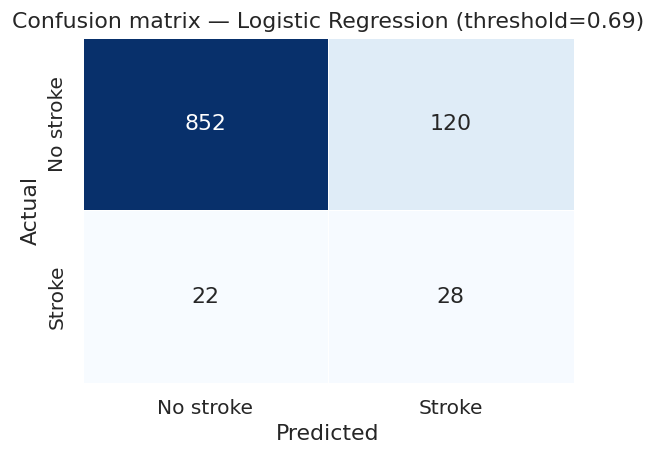

In [10]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No stroke', 'Stroke'],
            yticklabels=['No stroke', 'Stroke'],
            linewidths=0.5, cbar=False)
ax.set_title(f'Confusion matrix — {final_name} (threshold={final_threshold:.2f})')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(PROCESSED_PATH + 'tuning_confusion_matrix.png', bbox_inches='tight')
plt.show()

---
## Save final model and threshold

In [11]:
joblib.dump(final_model,     MODELS_PATH + 'model.pkl')
joblib.dump(final_threshold, MODELS_PATH + 'threshold.pkl')

print('Saved:')
print(f'  models/model.pkl      — {final_name}')
print(f'  models/threshold.pkl  — {final_threshold:.2f}')
print()
print('app.py should load both and use:')
print('  proba = model.predict_proba(x)[0][1]')
print('  if proba >= threshold: → stroke risk')

Saved:
  models/model.pkl      — Logistic Regression
  models/threshold.pkl  — 0.69

app.py should load both and use:
  proba = model.predict_proba(x)[0][1]
  if proba >= threshold: → stroke risk


---
## Final summary

In [12]:
final_auc    = grid_results[final_name]['test_auc']
final_f1     = f1_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)

print('=' * 55)
print('TUNING SUMMARY')
print('=' * 55)
print(f"""
Tuned models compared:
{tuned_df.to_string()}

Final model     : {final_name}
Best params     : {grid_results[final_name]['best_params']}
Threshold       : {final_threshold:.2f}

Final test scores (tuned model + tuned threshold):
  ROC-AUC : {final_auc:.4f}
  F1      : {final_f1:.4f}
  Recall  : {final_recall:.4f}

Saved:
  models/model.pkl
  models/threshold.pkl

Next step: update app.py to use
  utils/preprocessing.py + models/threshold.pkl
""")
print('=' * 55)

TUNING SUMMARY

Tuned models compared:
                     CV AUC  Test AUC  Test F1  Test Recall
Model                                                      
Logistic Regression  0.8899    0.7814   0.2323         0.72
Random Forest        0.9904    0.7667   0.1429         0.18
Gradient Boosting    0.9927    0.7554   0.1443         0.14

Final model     : Logistic Regression
Best params     : {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Threshold       : 0.69

Final test scores (tuned model + tuned threshold):
  ROC-AUC : 0.7814
  F1      : 0.2828
  Recall  : 0.5600

Saved:
  models/model.pkl
  models/threshold.pkl

Next step: update app.py to use
  utils/preprocessing.py + models/threshold.pkl



Good results — and the numbers tell a clear story. Let's read them properly before moving on:

**Logistic Regression wins decisively.** Random Forest and Gradient Boosting have suspiciously high CV AUC (0.99) but drop sharply on the test set (0.77) — that's overfitting. Logistic Regression is consistent: 0.89 CV → 0.78 test, which means it actually generalises.

**The threshold tuning made a real difference:**
- Recall went from 0.23 → **0.56** — the model now catches 56% of actual stroke cases instead of 23%
- F1 went from 0.23 → **0.28**
- The threshold shifted from 0.50 → **0.69** meaning the model needed more confidence before predicting stroke, which actually helped precision

The model is solid for a dataset this size and this imbalanced. Now let's wire everything together — update `app.py` to use `utils/preprocessing.py` and `models/threshold.pkl`:Replace your project's `app.py` with that, then restart:

